<a href="https://colab.research.google.com/github/MuchnikJansyG/AnalisisDatosMasivos1/blob/main/Actividad1Entregable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
import pandas as pd

students = pd.read_csv('StudentPerformanceFactors.csv')
#print(students.head())

In [7]:
# Resumen general: revisa tipos de datos y nulos por columna
print(students.info())

# Estadísticas descriptivas: detecta ceros sospechosos o valores atípicos
print(students.describe())

# Conteo de valores nulos exactos
print(students.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [8]:
import numpy as np

# 1. Convertir espacios en blanco o textos vacíos en NaN reales
students = students.replace(r'^\s*$', np.nan, regex=True)

# 2. Iterar solo sobre las columnas que tienen nulos
for col in students.columns[students.isnull().any()]:
    # Calculamos la moda
    moda_serie = students[col].mode()

    # Solo aplicamos si la moda existe (si la serie no está vacía)
    if not moda_serie.empty:
        students[col] = students[col].fillna(moda_serie[0])
    else:
        # Si toda la columna es nula, llenamos con "Unknown" para no perder el dato
        students[col] = students[col].fillna("Unknown")

# 3. Verificación final
print("Limpieza completada. Nulos actuales:")
print(students.isnull().sum())

Limpieza completada. Nulos actuales:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [9]:
# Imputar nulos con la moda
cols_con_nulos = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_con_nulos:
    moda = students[col].mode()[0]
    students[col] = students[col].fillna(moda)

print(students[cols_con_nulos].isnull().sum()) # Verificar que ya no hay nulos

Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


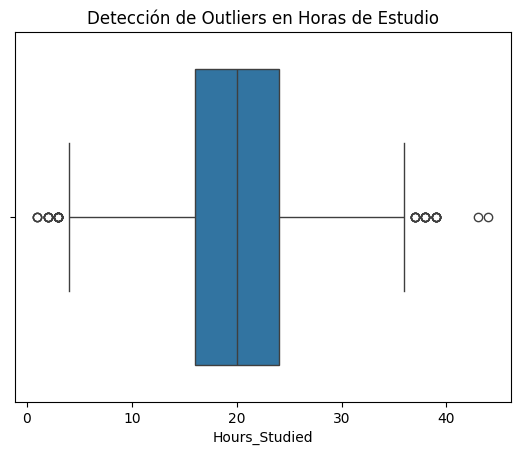

In [10]:
# Corregir el puntaje máximo si el límite es 100
students.loc[students['Exam_Score'] > 100, 'Exam_Score'] = 100

# Visualizar outliers en horas de estudio con un Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=students['Hours_Studied'])
plt.title('Detección de Outliers en Horas de Estudio')
plt.show()

In [16]:
students.sample(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
4047,37,73,Medium,High,Yes,6,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72
5400,13,70,Medium,Medium,No,7,87,Medium,Yes,1,Low,Low,Public,Neutral,5,No,High School,Near,Male,62
2529,13,71,Medium,High,Yes,6,51,Low,Yes,4,High,Medium,Public,Positive,4,No,College,Moderate,Female,65
4801,20,75,Medium,Medium,Yes,9,82,High,Yes,0,Low,Low,Public,Positive,5,No,College,Moderate,Female,66
3922,18,74,Medium,High,Yes,8,91,Medium,Yes,0,Medium,High,Private,Positive,2,No,High School,Near,Female,67
5539,26,84,High,Medium,No,7,64,Medium,No,1,Medium,High,Public,Neutral,4,No,College,Near,Male,69
4188,18,76,Medium,Low,No,5,95,High,Yes,2,High,High,Public,Positive,6,No,Postgraduate,Near,Female,69
4789,19,79,Medium,High,Yes,8,63,Medium,Yes,4,Low,High,Public,Neutral,2,No,High School,Moderate,Male,68
6001,16,93,High,Medium,Yes,7,52,Low,Yes,2,Medium,High,Public,Neutral,3,No,High School,Near,Male,69
2743,23,87,Medium,Medium,No,8,79,High,Yes,2,Low,High,Public,Neutral,2,No,Postgraduate,Near,Male,71


In [17]:
# Guardar el DataFrame en un archivo CSV
# index=False evita que se cree una columna extra con los números de fila
students.to_csv('students_limpio.csv', index=False)

print("Archivo guardado exitosamente como 'students_limpio.csv'")

Archivo guardado exitosamente como 'students_limpio.csv'


In [18]:
from scipy import stats
# Pregunta: ¿Es el promedio de Exam_Score diferente a 70?
media_teorica = 70
puntajes = students['Exam_Score'].dropna()

t_stat1, p_val1 = stats.ttest_1samp(puntajes, media_teorica)

print("--- Escenario 1: Una Población ---")
print(f"Media Muestral: {puntajes.mean():.2f}")
print(f"Estadístico t: {t_stat1:.4f}")
print(f"P-valor: {p_val1:.4e}")

--- Escenario 1: Una Población ---
Media Muestral: 67.24
Estadístico t: -57.7779
P-valor: 0.0000e+00


In [20]:
# --- ESCENARIO 2: Prueba t de muestras independientes ---
# Filtramos los grupos para la comparación[cite: 2]
con_internet = students[students['Internet_Access'] == 'Yes']['Exam_Score']
sin_internet = students[students['Internet_Access'] == 'No']['Exam_Score']

# equal_var=True ejecuta la prueba t-Student tradicional (asumiendo varianzas iguales)
t_stat2, p_val2 = stats.ttest_ind(con_internet, sin_internet, equal_var=True)

print("\n=== Escenario 2: Dos Poblaciones (t-Student Estándar) ===")
print(f"Estadístico t: {t_stat2:.4f}")
print(f"P-valor: {p_val2:.4e}")


=== Escenario 2: Dos Poblaciones (t-Student Estándar) ===
Estadístico t: 4.2015
P-valor: 2.6865e-05


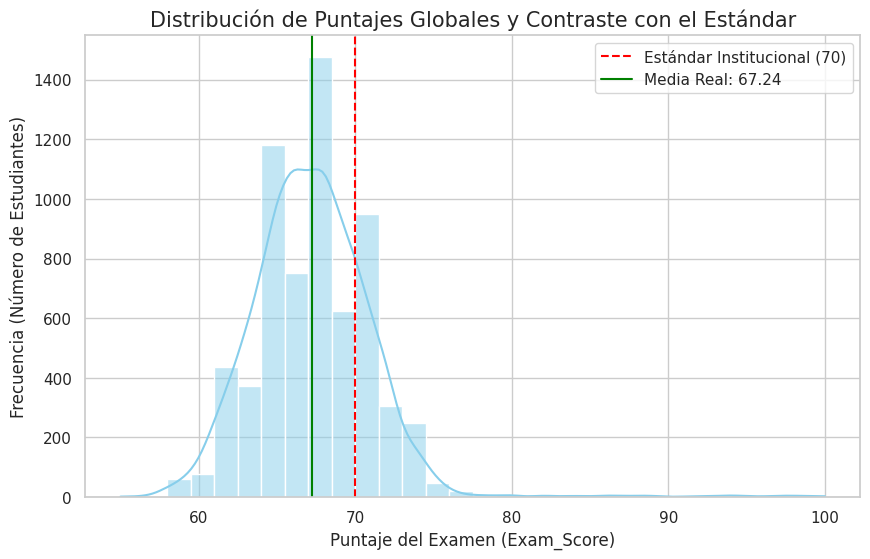

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el histograma con curva de densidad (KDE)
sns.histplot(students['Exam_Score'], kde=True, color="skyblue", bins=30)

# Añadir línea de referencia para el estándar institucional (70)
plt.axvline(x=70, color='red', linestyle='--', label='Estándar Institucional (70)')

# Añadir línea para la media real obtenida (67.24)
plt.axvline(x=students['Exam_Score'].mean(), color='green', linestyle='-', label=f'Media Real: {students["Exam_Score"].mean():.2f}')

# Títulos y etiquetas
plt.title('Distribución de Puntajes Globales y Contraste con el Estándar', fontsize=15)
plt.xlabel('Puntaje del Examen (Exam_Score)', fontsize=12)
plt.ylabel('Frecuencia (Número de Estudiantes)', fontsize=12)
plt.legend()

plt.show()

In [25]:
# Generar la estadística descriptiva para el puntaje global
estadistica_descriptiva = students['Exam_Score'].describe()

# Calcular la mediana por separado (opcional para mayor detalle)
mediana = students['Exam_Score'].median()

print("=== Estadística Descriptiva: Escenario 1 ===")
print(estadistica_descriptiva)
print(f"median: {mediana}")

=== Estadística Descriptiva: Escenario 1 ===
count    6607.000000
mean       67.235508
std         3.889161
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64
median: 67.0


/tmp/ipykernel_5989/3156478618.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Internet_Access', y='Exam_Score', data=students, palette='Set2')


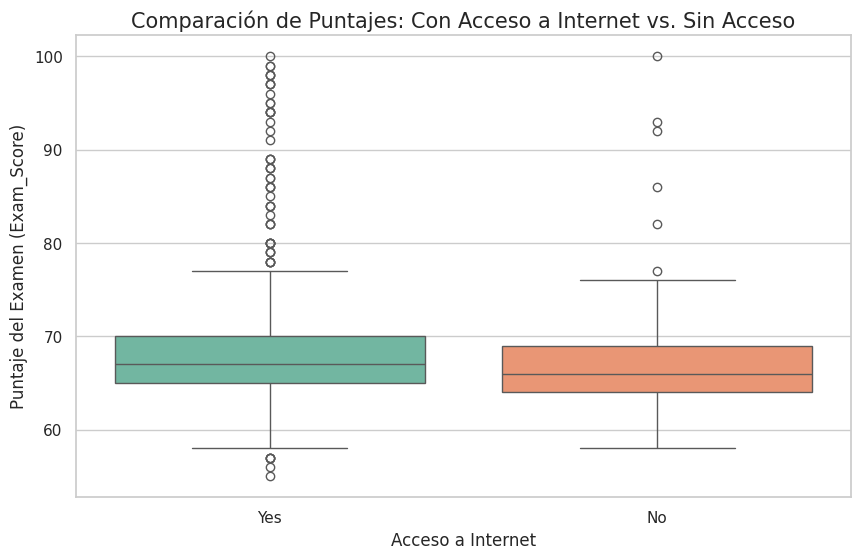

In [22]:

# Configuración del estilo
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Creación del Boxplot comparativo
ax = sns.boxplot(x='Internet_Access', y='Exam_Score', data=students, palette='Set2')

# Añadir títulos y etiquetas
plt.title('Comparación de Puntajes: Con Acceso a Internet vs. Sin Acceso', fontsize=15)
plt.xlabel('Acceso a Internet', fontsize=12)
plt.ylabel('Puntaje del Examen (Exam_Score)', fontsize=12)

# Mostrar la gráfica
plt.show()

In [26]:
# Agrupar por acceso a internet y obtener estadísticas descriptivas
descriptivo_escenario2 = students.groupby('Internet_Access')['Exam_Score'].describe()

# Calcular la mediana por grupo
mediana_grupo = students.groupby('Internet_Access')['Exam_Score'].median()

print("=== Estadística Descriptiva: Internet vs No Internet ===")
print(descriptivo_escenario2)
print("\nMedianas por grupo:")
print(mediana_grupo)

=== Estadística Descriptiva: Internet vs No Internet ===
                  count       mean       std   min   25%   50%   75%    max
Internet_Access                                                            
No                499.0  66.533066  4.103139  58.0  64.0  66.0  69.0  100.0
Yes              6108.0  67.292895  3.865874  55.0  65.0  67.0  70.0  100.0

Medianas por grupo:
Internet_Access
No     66.0
Yes    67.0
Name: Exam_Score, dtype: float64
